In [1]:
!pip install -q braindecode moabb mne torch torchvision torchaudio scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.8/448.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.1/279.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.5/253.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 r

BNCI 2014-001 motor imagery EEG dataset.

More precisely:

Dataset name: BNCI2014_001

Task type: Motor imagery classification

Subjects: You selected subject 1

Classes: 4 motor imagery classes (the 4 labels you mapped to 0–3)

Channels: 22 EEG channels

Sampling rate: ~250 Hz

Trials: 576 trials total for subject 1

Trial window you’re using: 0.5–2.5 seconds after cue (2-second window)

This dataset is part of the BNCI Horizon 2020 EEG database, and it’s widely used as a benchmark dataset in EEG decoding papers, including many EEGNet examples.


In [2]:
import braindecode
import moabb
import mne
print("Imports successful!")

Imports successful!


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


PyTorch version: 2.9.0+cu126
GPU available: True
GPU name: Tesla T4


In [4]:
import warnings
warnings.filterwarnings("ignore")

from braindecode.datasets import MOABBDataset

# Motor imagery dataset that downloads automatically
dataset = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[1])

print("Number of recordings:", len(dataset.datasets))
print("Description columns:", dataset.description.columns.tolist())
print(dataset.description.head())


100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 73.3GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.8M/43.8M [00:00<00:00, 67.6GB/s]
SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Number of recordings: 12
Description columns: ['subject', 'session', 'run']
   subject session run
0        1  0train   0
1        1  0train   1
2        1  0train   2
3        1  0train   3
4        1  0train   4


In [5]:
from braindecode.preprocessing import preprocess, Preprocessor

# Check sampling rate from the first recording
sfreq = dataset.datasets[0].raw.info["sfreq"]
print("Sampling rate (Hz):", sfreq)

preprocessors = [
    Preprocessor("pick_types", eeg=True, meg=False, stim=False, eog=False),
    Preprocessor("filter", l_freq=1.0, h_freq=40.0),
    Preprocessor(lambda x: x * 1e6),  # convert V -> µV
]

preprocess(dataset, preprocessors)

print("Preprocessing complete.")
print("Channels after preprocessing:", len(dataset.datasets[0].raw.ch_names))
print("First 5 channel names:", dataset.datasets[0].raw.ch_names[:5])


Sampling rate (Hz): 250.0
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window wit

In [12]:
import numpy as np
import mne

X_list, y_list = [], []

tmin, tmax = 0.5, 2.5  # seconds after cue (2 seconds window)

for i, ds in enumerate(dataset.datasets):
    raw = ds.raw

    # Get events and event_id from annotations
    events, event_id = mne.events_from_annotations(raw, verbose=False)

    # Keep only actual task events (drop rest if present)
    # (event_id keys vary; we’ll just use whatever MNE extracted)
    picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False)

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        picks=picks,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    # epochs.get_data() -> (n_epochs, n_channels, n_times)
    X_run = epochs.get_data()
    y_run = epochs.events[:, -1]  # numeric event codes

    X_list.append(X_run)
    y_list.append(y_run)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print("X shape (trials, channels, samples):", X.shape)
print("Unique event codes in y:", np.unique(y))
print("Number of trials:", len(y))


X shape (trials, channels, samples): (576, 22, 501)
Unique event codes in y: [1 2 3 4]
Number of trials: 576


In [13]:
event_id

{np.str_('feet'): 1,
 np.str_('left_hand'): 2,
 np.str_('right_hand'): 3,
 np.str_('tongue'): 4}

event_id mapping: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
First 5 events [sample, prev, code]:
 [[ 750    0    4]
 [2753    0    1]
 [4671    0    3]
 [6623    0    2]
 [8631    0    2]]

Chosen event code: 4 at time (sec): 3.0
Using matplotlib as 2D backend.


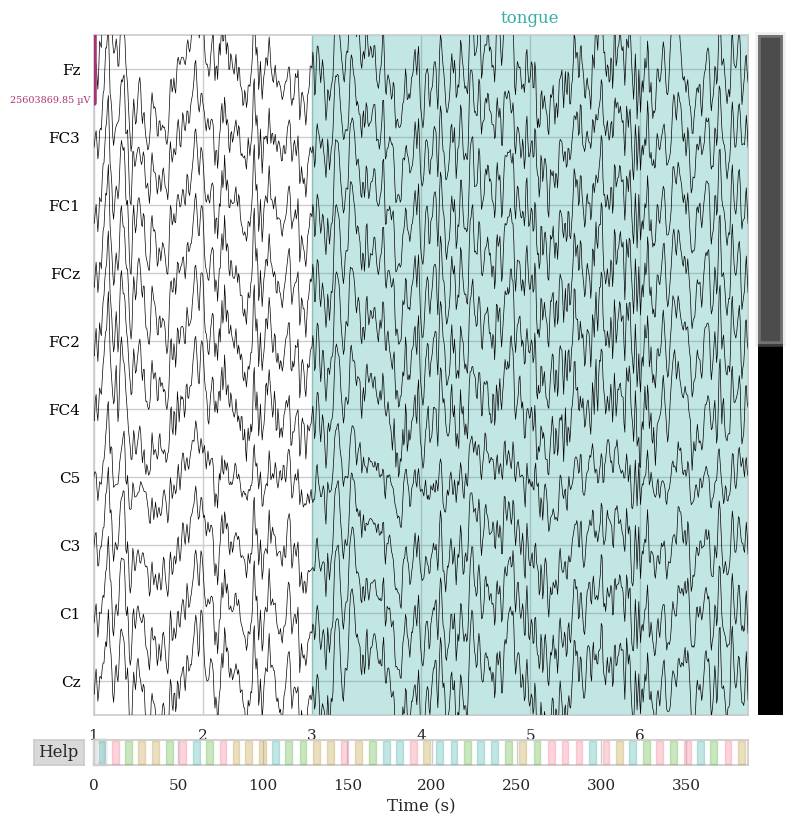


Epochs shape (trials, channels, samples): (48, 22, 501)


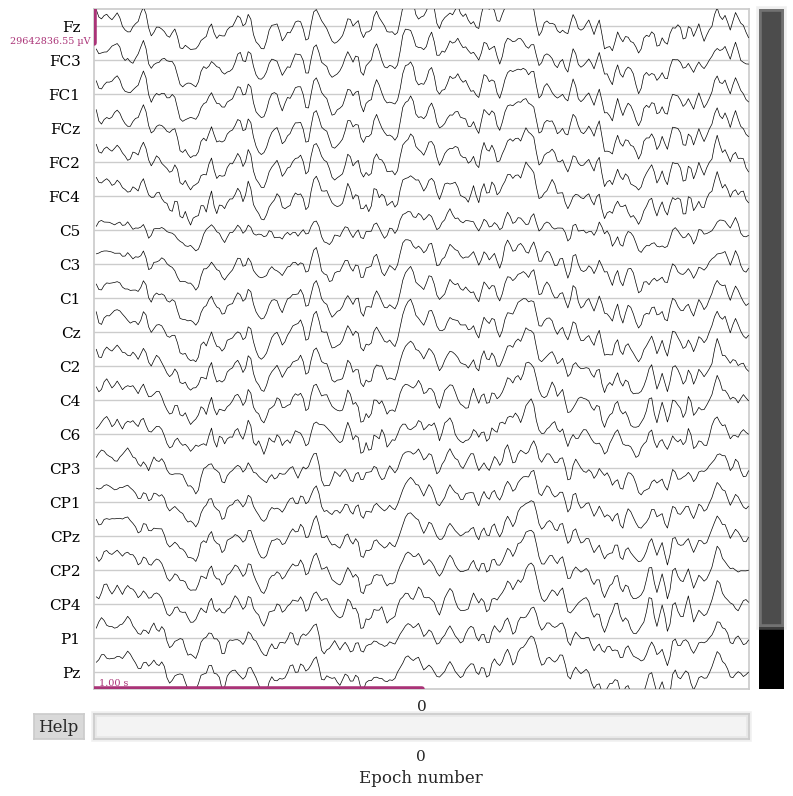

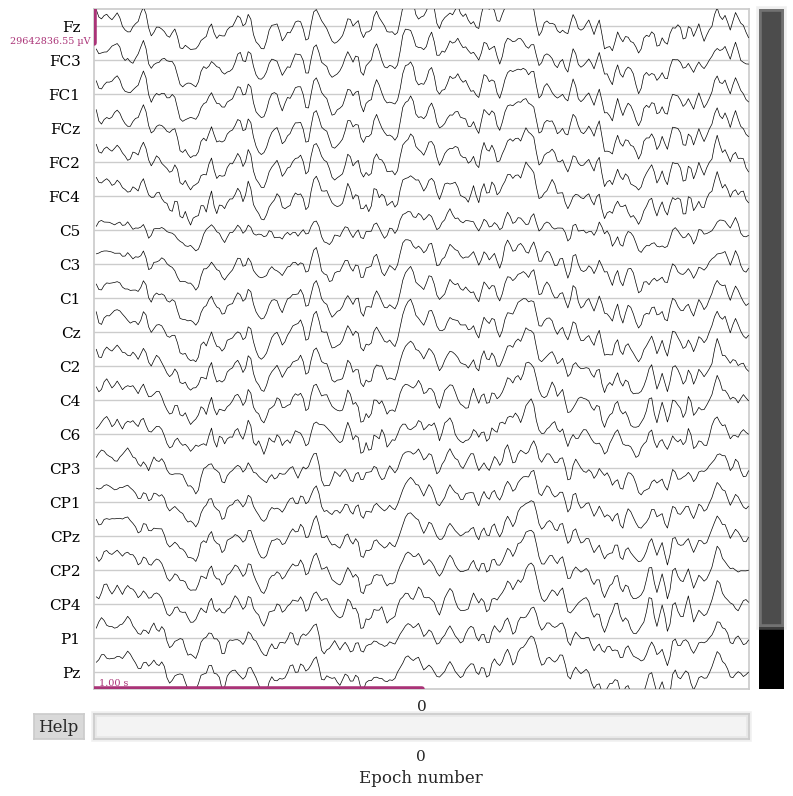

In [14]:
import mne
import numpy as np

# Pick one run/recording
raw = dataset.datasets[0].raw

# Get events from annotations
events, event_id = mne.events_from_annotations(raw, verbose=False)

print("event_id mapping:", event_id)
print("First 5 events [sample, prev, code]:\n", events[:5])

sfreq = raw.info["sfreq"]

# Pick the first event
event_sample = events[0, 0]
event_code = events[0, 2]
event_time_sec = event_sample / sfreq

print("\nChosen event code:", event_code, "at time (sec):", event_time_sec)

# Show raw EEG around the event: 2s before to 4s after
t_start = max(event_time_sec - 2.0, 0)
duration = 6.0

raw.plot(
    start=t_start,
    duration=duration,
    n_channels=10,
    scalings="auto",
    show=True,
    title="Raw EEG around one event (vertical line = event time)"
)

# Also show the epoch we will cut from 0.5s to 2.5s after the cue
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0.5,
    tmax=2.5,
    picks=mne.pick_types(raw.info, eeg=True, stim=False, eog=False),
    baseline=None,
    preload=True,
    reject_by_annotation=True,
    verbose=False
)

print("\nEpochs shape (trials, channels, samples):", epochs.get_data().shape)

# Plot the first epoch (trial) for a quick look
epochs[0].plot(scalings="auto", title="First epoch (0.5s to 2.5s after cue)")


In [15]:
import mne
import numpy as np

raw = dataset.datasets[0].raw
events, event_id = mne.events_from_annotations(raw, verbose=False)

# 1) Show all annotations in this run
print("Total annotations in this run:", len(raw.annotations))
print("\nFirst 15 annotations (onset sec, duration sec, description):")
for a in raw.annotations[:15]:
    print(f"onset={a['onset']:.3f}s  dur={a['duration']:.3f}s  desc={a['description']}")

# 2) Identify "bad" annotations (anything that contains 'bad' is treated as rejectable)
bad_anns = [a for a in raw.annotations if "bad" in a["description"].lower()]
print("\nBad annotations found:", len(bad_anns))
for a in bad_anns[:10]:
    print(f"BAD -> onset={a['onset']:.3f}s  dur={a['duration']:.3f}s  desc={a['description']}")

picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False)

# 3) Make epochs WITHOUT removing bad annotations
epochs_keep = mne.Epochs(
    raw, events, event_id=event_id,
    tmin=0.5, tmax=2.5, picks=picks,
    baseline=None, preload=True,
    reject_by_annotation=False,  # keep everything
    verbose=False
)

# 4) Make epochs WITH removing bad annotations
epochs_drop = mne.Epochs(
    raw, events, event_id=event_id,
    tmin=0.5, tmax=2.5, picks=picks,
    baseline=None, preload=True,
    reject_by_annotation=True,   # drop epochs overlapping BAD segments
    verbose=False
)

print("\nEpoch count WITHOUT reject_by_annotation:", len(epochs_keep))
print("Epoch count WITH    reject_by_annotation:", len(epochs_drop))
print("Dropped due to annotations:", len(epochs_keep) - len(epochs_drop))

# 5) Show which epochs were dropped and why
epochs_drop.drop_log  # list of reasons per epoch
dropped_idx = [i for i, r in enumerate(epochs_drop.drop_log) if len(r) > 0]
print("\nFirst 20 dropped epoch indices:", dropped_idx[:20])

if len(dropped_idx) > 0:
    print("\nExample drop reason for the first dropped epoch:")
    print("Epoch index:", dropped_idx[0], "Reason:", epochs_drop.drop_log[dropped_idx[0]])


Total annotations in this run: 48

First 15 annotations (onset sec, duration sec, description):
onset=3.000s  dur=4.000s  desc=tongue
onset=11.012s  dur=4.000s  desc=feet
onset=18.684s  dur=4.000s  desc=right_hand
onset=26.492s  dur=4.000s  desc=left_hand
onset=34.524s  dur=4.000s  desc=left_hand
onset=42.968s  dur=4.000s  desc=right_hand
onset=50.636s  dur=4.000s  desc=feet
onset=58.836s  dur=4.000s  desc=tongue
onset=66.560s  dur=4.000s  desc=right_hand
onset=74.552s  dur=4.000s  desc=feet
onset=82.176s  dur=4.000s  desc=left_hand
onset=89.756s  dur=4.000s  desc=left_hand
onset=97.644s  dur=4.000s  desc=left_hand
onset=105.420s  dur=4.000s  desc=tongue
onset=113.288s  dur=4.000s  desc=right_hand

Bad annotations found: 0

Epoch count WITHOUT reject_by_annotation: 48
Epoch count WITH    reject_by_annotation: 48
Dropped due to annotations: 0

First 20 dropped epoch indices: []


In [16]:
import numpy as np
from collections import Counter

# Map event codes to 0..3
code_to_class = {1: 0, 2: 1, 3: 2, 4: 3}
y_class = np.array([code_to_class[v] for v in y])

print("Unique y_class:", np.unique(y_class))
print("Class counts:", Counter(y_class))

# Optional: simple per-trial normalization (good baseline for EEGNet)
X_norm = (X - X.mean(axis=-1, keepdims=True)) / (X.std(axis=-1, keepdims=True) + 1e-8)

print("X_norm shape:", X_norm.shape)


Unique y_class: [0 1 2 3]
Class counts: Counter({np.int64(3): 144, np.int64(0): 144, np.int64(2): 144, np.int64(1): 144})
X_norm shape: (576, 22, 501)


In [17]:
from sklearn.model_selection import train_test_split
import numpy as np

# X_norm: (N, C, T)
# EEGNetv4 in Braindecode expects (N, C, T) -> we're already in the right shape.

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train label counts:", np.bincount(y_train))
print("Test label counts:", np.bincount(y_test))


Train shape: (460, 22, 501) Test shape: (116, 22, 501)
Train label counts: [115 115 115 115]
Test label counts: [29 29 29 29]


In [19]:
import torch
import numpy as np
from braindecode.models import EEGNetv4
from braindecode.classifier import EEGClassifier
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit
from sklearn.metrics import accuracy_score

n_chans = X_train.shape[1]
n_times = X_train.shape[2]
n_classes = len(np.unique(y_train))

model = EEGNetv4(
    n_chans=n_chans,
    n_outputs=n_classes,
    n_times=n_times
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

clf = EEGClassifier(
    module=model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    optimizer__lr=1e-3,
    batch_size=32,
    max_epochs=200,
    train_split=ValidSplit(0.2, stratified=True, random_state=42),  # <-- key fix
    callbacks=[EarlyStopping(monitor="valid_loss", patience=20)],    # now valid_loss exists
    device=device,
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)


Using device: cuda
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.3733       0.3370        1.3811  0.3501
      2        1.3126       0.3043        1.3796  0.2835
      3        1.2812       0.3261        1.3760  0.3196
      4        1.2361       0.3261        1.3715  0.1720
      5        1.1995       0.3370        1.3677  0.1813
      6        1.1531       0.3587        1.3616  0.2035
      7        1.1310       0.3261        1.3621  0.1538
      8        1.0984       0.3043        1.3606  0.1384
      9        1.0585       0.2717        1.3618  0.1295
     10        0.9935       0.3043        1.3725  0.1335
     11        0.9051       0.2826        1.3728  0.1493
     12        0.8729       0.3043        1.4076  0.1235
     13        0.8586       0.3152        1.4731  0.1873
     14        0.8144       0.3478        1.5229  0.1390
     15        0.7720       0.3043        1.5414  0.2018
     16     

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=3))


Confusion matrix (rows=true, cols=pred):
 [[ 7 11 11  0]
 [ 0 10 19  0]
 [ 0  5 24  0]
 [ 6 10  8  5]]

Classification report:

              precision    recall  f1-score   support

           0      0.538     0.241     0.333        29
           1      0.278     0.345     0.308        29
           2      0.387     0.828     0.527        29
           3      1.000     0.172     0.294        29

    accuracy                          0.397       116
   macro avg      0.551     0.397     0.366       116
weighted avg      0.551     0.397     0.366       116



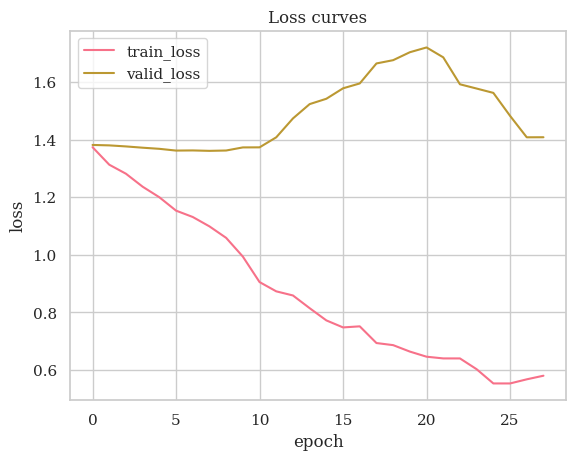

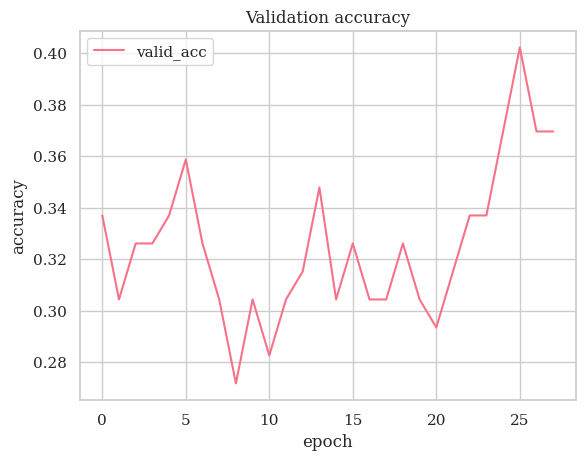

In [21]:
import matplotlib.pyplot as plt

hist = clf.history

train_loss = hist[:, 'train_loss']
valid_loss = hist[:, 'valid_loss']
valid_acc  = hist[:, 'valid_acc']

plt.figure()
plt.plot(train_loss, label='train_loss')
plt.plot(valid_loss, label='valid_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Loss curves')
plt.show()

plt.figure()
plt.plot(valid_acc, label='valid_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Validation accuracy')
plt.show()


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import mne
import torch

from braindecode.preprocessing import preprocess, Preprocessor
from braindecode.models import EEGNetv4
from braindecode.classifier import EEGClassifier
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

# ---------- 1) Re-load dataset fresh (so we don't double-filter the same data) ----------
from braindecode.datasets import MOABBDataset
dataset2 = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[1])

sfreq = dataset2.datasets[0].raw.info["sfreq"]
print("Sampling rate:", sfreq)

# ---------- 2) Preprocess: pick EEG, bandpass 4-38, notch 60 ----------
preprocessors = [
    Preprocessor("pick_types", eeg=True, meg=False, stim=False, eog=False),
    Preprocessor("filter", l_freq=4.0, h_freq=38.0),
    Preprocessor("notch_filter", freqs=60.0),
    Preprocessor(lambda x: x * 1e6),
]
preprocess(dataset2, preprocessors)
print("Preprocessing complete (4-38 Hz + notch 60).")

# ---------- 3) Epoching: 0.5 to 2.5s after cue ----------
X_list, y_list = [], []
tmin, tmax = 0.5, 2.5

for ds in dataset2.datasets:
    raw = ds.raw
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False)

    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=tmin, tmax=tmax,
        picks=picks, baseline=None,
        preload=True, reject_by_annotation=True,
        verbose=False
    )
    X_list.append(epochs.get_data())
    y_list.append(epochs.events[:, -1])

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print("X shape:", X.shape, "unique event codes:", np.unique(y))

# ---------- 4) Map labels 1..4 -> 0..3 ----------
code_to_class = {1: 0, 2: 1, 3: 2, 4: 3}
y_class = np.array([code_to_class[v] for v in y])

print("Class counts:", Counter(y_class))

# ---------- 5) Normalize per trial ----------
X_norm = (X - X.mean(axis=-1, keepdims=True)) / (X.std(axis=-1, keepdims=True) + 1e-8)

# ---------- 6) Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_class,
    test_size=0.2, random_state=42, stratify=y_class
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# ---------- 7) EEGNet training ----------
n_chans, n_times = X_train.shape[1], X_train.shape[2]
n_classes = len(np.unique(y_train))

model = EEGNetv4(n_chans=n_chans, n_outputs=n_classes, n_times=n_times)

device = "cuda" if torch.cuda.is_available() else "cpu"
clf2 = EEGClassifier(
    module=model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    optimizer__lr=1e-3,
    batch_size=32,
    max_epochs=200,
    train_split=ValidSplit(0.2, stratified=True, random_state=42),
    callbacks=[EarlyStopping(monitor="valid_loss", patience=20)],
    device=device,
)

clf2.fit(X_train, y_train)

y_pred = clf2.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("New test accuracy:", acc)


Sampling rate: 250.0
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 38 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 38.00 Hz
- Upper transition bandwidth: 9.50 Hz (-6 dB cutoff frequency: 42.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.

In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import mne
import torch

from braindecode.datasets import MOABBDataset
from braindecode.preprocessing import preprocess, Preprocessor
from braindecode.preprocessing.preprocess import exponential_moving_standardize

from braindecode.models import EEGNetv4
from braindecode.classifier import EEGClassifier
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

# 1) Reload fresh
dataset3 = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[1])
sfreq = dataset3.datasets[0].raw.info["sfreq"]
print("Sampling rate:", sfreq)

# 2) Preprocess: pick EEG, bandpass 1-40, convert to µV, then EMS
preprocessors = [
    Preprocessor("pick_types", eeg=True, meg=False, stim=False, eog=False),
    Preprocessor("filter", l_freq=1.0, h_freq=40.0),
    Preprocessor(lambda x: x * 1e6),
    Preprocessor(exponential_moving_standardize, factor_new=1e-3, init_block_size=int(sfreq)),
]
preprocess(dataset3, preprocessors)
print("Preprocessing complete (1-40 Hz + EMS).")

# 3) Epoching: 0.5 to 2.5s after cue
X_list, y_list = [], []
tmin, tmax = 0.5, 2.5

for ds in dataset3.datasets:
    raw = ds.raw
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False)

    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=tmin, tmax=tmax,
        picks=picks, baseline=None,
        preload=True, reject_by_annotation=True,
        verbose=False
    )
    X_list.append(epochs.get_data())
    y_list.append(epochs.events[:, -1])

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

# 4) Map labels
code_to_class = {1: 0, 2: 1, 3: 2, 4: 3}
y_class = np.array([code_to_class[v] for v in y])

print("X shape:", X.shape)
print("Class counts:", Counter(y_class))

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# 6) EEGNet training
n_chans, n_times = X_train.shape[1], X_train.shape[2]
n_classes = len(np.unique(y_train))

model = EEGNetv4(n_chans=n_chans, n_outputs=n_classes, n_times=n_times)

device = "cuda" if torch.cuda.is_available() else "cpu"
clf3 = EEGClassifier(
    module=model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    optimizer__lr=1e-3,
    batch_size=32,
    max_epochs=200,
    train_split=ValidSplit(0.2, stratified=True, random_state=42),
    callbacks=[EarlyStopping(monitor="valid_loss", patience=20)],
    device=device,
)

clf3.fit(X_train, y_train)

y_pred = clf3.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy with EMS:", acc)


Sampling rate: 250.0
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0

In [24]:
import torch, json, time
from pathlib import Path

# Make a folder
Path("outputs").mkdir(exist_ok=True)

# 1) Save model parameters (weights)
torch.save(clf3.module_.state_dict(), "outputs/eegnet_bnci2014_subject1_ems.pt")

# 2) Save a small config file so you remember what worked
config = {
    "dataset": "BNCI2014_001",
    "subject_ids": [1],
    "sfreq": float(sfreq),
    "tmin_sec": 0.5,
    "tmax_sec": 2.5,
    "preprocess": [
        "pick_types(eeg=True)",
        "filter(1-40 Hz)",
        "convert to microvolts",
        "exponential_moving_standardize(factor_new=1e-3, init_block_size=sfreq)"
    ],
    "model": "EEGNetv4 (braindecode)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "batch_size": 32,
    "max_epochs": 200,
    "early_stopping_patience": 20,
    "test_accuracy": 0.7413793103448276,
    "saved_weights": "outputs/eegnet_bnci2014_subject1_ems.pt",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}

with open("outputs/run_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(" - outputs/eegnet_bnci2014_subject1_ems.pt")
print(" - outputs/run_config.json")


Saved:
 - outputs/eegnet_bnci2014_subject1_ems.pt
 - outputs/run_config.json


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf3.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=3))


Confusion matrix (rows=true, cols=pred):
 [[21  2  2  4]
 [ 3 19  4  3]
 [ 2  4 22  1]
 [ 4  1  0 24]]

Classification report:

              precision    recall  f1-score   support

           0      0.700     0.724     0.712        29
           1      0.731     0.655     0.691        29
           2      0.786     0.759     0.772        29
           3      0.750     0.828     0.787        29

    accuracy                          0.741       116
   macro avg      0.742     0.741     0.740       116
weighted avg      0.742     0.741     0.740       116



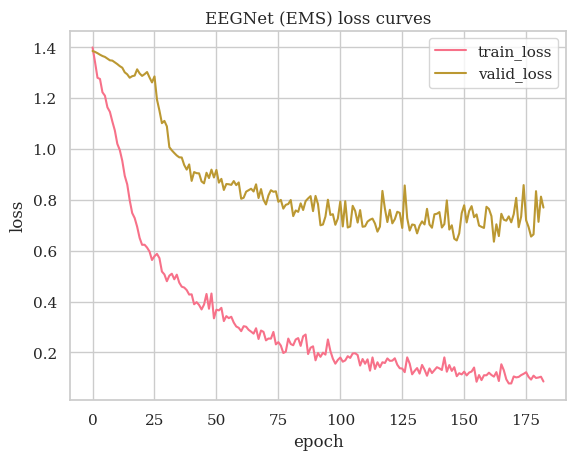

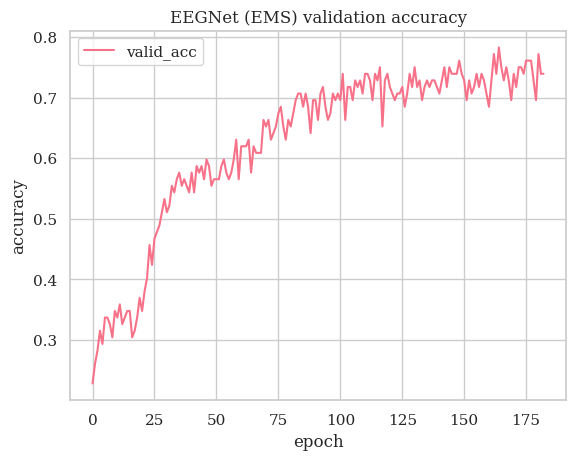

In [26]:
import matplotlib.pyplot as plt

hist = clf3.history

train_loss = hist[:, "train_loss"]
valid_loss = hist[:, "valid_loss"]
valid_acc  = hist[:, "valid_acc"]

plt.figure()
plt.plot(train_loss, label="train_loss")
plt.plot(valid_loss, label="valid_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("EEGNet (EMS) loss curves")
plt.show()

plt.figure()
plt.plot(valid_acc, label="valid_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("EEGNet (EMS) validation accuracy")
plt.show()
